# **<font color="#4863A0"> UTS Text Modelling : Text Clasification (Supervised) </font>**

**Nama** : **Joe Ifmanur Alfarizi**

**NPM** : **2206826015**


**<font color="#4863A0">Kelas Analisis Data Tidak Terstruktur (B)**

**Dosen Pengampu : Dr. Eng. Arie Wahyu Wijayanto, SST, MT.**

#Data Preparation

In [ ]:
!gdown 1DBcmKfxrdC8LtLoUu4ZVEaHVV4DRiGUE

Downloading...
From: https://drive.google.com/uc?id=1DBcmKfxrdC8LtLoUu4ZVEaHVV4DRiGUE
To: /content/Ulasan Spotify.csv
100% 5.57M/5.57M [00:00<00:00, 88.3MB/s]


In [ ]:
import pandas as pd

import string

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split as tts

from tensorflow.keras.preprocessing.text import Tokenizer

import numpy as np

from keras.preprocessing.sequence import pad_sequences

from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import History

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import numpy as np

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df = pd.read_csv("/content/Ulasan Spotify.csv", sep=';')
df

,Ulasan,Label
0,suka banget sama ni app,Positif
1,bgus,Positif
2,ga bisa denger lagu JKT48 lagi gara² selalu di...,Negatif
3,lagunya bagus banget buat ngapa ngapain,Positif
4,"kenapa sih, aku cuman bisa main 5 lagu doang? ...",Negatif
...,...,...
99997,"Aplikasi ini bagus sekali, namun sayangnya keb...",Negatif
99998,Bagu bgt,Positif
99999,Sangat rekomendasi in aplikasi bagus bener,Positif
100000,Asik tp berbayar wkwkwkk,Positif


#Preprocessing Data

Cek Missing Value dan Duplicate

In [ ]:
print('Missing value:')
print(df.isnull().sum())

print('\n\nData duplikat:')
print(df.duplicated().sum())

Missing value:
Ulasan    1
Label     2
dtype: int64


Data duplikat:
30435


Buang Missing Value dan buang Duplicate

In [ ]:
data = df.dropna().drop_duplicates()
data

,Ulasan,Label
0,suka banget sama ni app,Positif
1,bgus,Positif
2,ga bisa denger lagu JKT48 lagi gara² selalu di...,Negatif
3,lagunya bagus banget buat ngapa ngapain,Positif
4,"kenapa sih, aku cuman bisa main 5 lagu doang? ...",Negatif
...,...,...
99996,Mantap pokok nya??,Positif
99997,"Aplikasi ini bagus sekali, namun sayangnya keb...",Negatif
99999,Sangat rekomendasi in aplikasi bagus bener,Positif
100000,Asik tp berbayar wkwkwkk,Positif


Mengubah semua huruf menjadi huruf kecil

In [ ]:
data['Ulasan'] = data['Ulasan'].str.lower()

Menghapus tanda baca

In [ ]:
def remove_punctuation(words):
    return words.translate(str.maketrans('','',string.punctuation))
data['Ulasan'] = data['Ulasan'].apply(remove_punctuation)

Menghapus stopword (yaitu kata-kata yang tidak memengaruhi sentimen)

In [ ]:
stop_word = [
    'yg',
    'yang',
    'di',
    'ini',
    'dan',
    'aja',
    'username',
    'itu',
    'ya'
]

def remove_stop_word(words):
    return [word for word in words if word not in stop_word]

data['Ulasan'] = data['Ulasan'].apply(word_tokenize)

data['Ulasan'] = data['Ulasan'].apply(remove_stop_word)

# Join lagi untuk melakukan EDA
data['Ulasan'] = data['Ulasan'].apply(' '.join)

In [ ]:
data

,Ulasan,Label
0,suka banget sama ni app,Positif
1,bgus,Positif
2,ga bisa denger lagu jkt48 lagi gara² selalu ta...,Negatif
3,lagunya bagus banget buat ngapa ngapain,Positif
4,kenapa sih aku cuman bisa main 5 lagu doang ki...,Negatif
...,...,...
99996,mantap pokok nya,Positif
99997,aplikasi bagus sekali namun sayangnya kebanyak...,Negatif
99999,sangat rekomendasi in aplikasi bagus bener,Positif
100000,asik tp berbayar wkwkwkk,Positif


#Exploratory Data Analysis (EDA)

Menganalisa contoh ulasan positif dan negatif

In [ ]:
for i in range(1,11):
    print('user #', i)
    ulasan_positif = df[df['Label'] == 'Positif']['Ulasan'].iloc[i]
    print(ulasan_positif + '\n')

user # 1
bgus

user # 2
lagunya bagus banget buat ngapa ngapain

user # 3
mantap!!

user # 4
bagus sih lagu nya asik asik

user # 5
bagus

user # 6
nemenin saat di perjalanan

user # 7
mantap

user # 8
good

user # 9
teman saat kesepian

user # 10
cuma dengerin ngak vidionya



Dari 10 contoh yang diberikan, dapat dilihat bahwa komentar dengan sentimen positif ditandai dengan apresiasi kepada spotify yang telah menemani pengguna dalam beraktivitas.

In [ ]:
for i in range(1,11):
    print('user #', i)
    ulasan_negatif = df[df['Label'] == 'Negatif']['Ulasan'].iloc[i]
    print(ulasan_negatif + '\n')

user # 1
kenapa sih, aku cuman bisa main 5 lagu doang? kirain ini gratis! gk bagus!

user # 2
saya tidak bisa buka aplikasi nya saya harap dapat di tindak lanjuti

user # 3
harga paket mahal

user # 4
banyak iklan mending MOD

user # 5
tidak ada lagu where we are

user # 6
yes

user # 7
sebenernya apk nya bagus tapi kenapa harus ada batasan mengganti lagu?, kan itu jarusnya tak ada batasan trs juga kalau saya ingin memencet lagu eh malah nyetel nya lagu lain,itu bukan karna salah pencet atau gmn ya,soalnya udh saya ulang berkali-kali dan hapus lagu nya dan saya coba putar lagi eh malah muncul lagu yang lain kan aneh mana lagunya sama trs lagi udh gitu iklannya banyak ???????

user # 8
ini kenapa kita tidak bisa putar lagu harus bayar ke mode premium. tiba" banget. lagunya kita nggak bisa milih mau lagu apa karena lagunya di atur.kecewa banget sama Spotify

user # 9
banyak iklan dan bug

user # 10
saya tidak bisa masuk saya tidak puas dengan spotify!!!!!



Dari 10 contoh komentar negatif, dapat dilihat bahwa komentar bersentimen negatif menunjukkan kekecewaan pengguna dengan iklan yang terlalu banyak, keterbatasan lagu dan fitur, dan biaya langganan yang cukup mahal menurut pengguna.

Perbandingan data Positif dan data Negatif

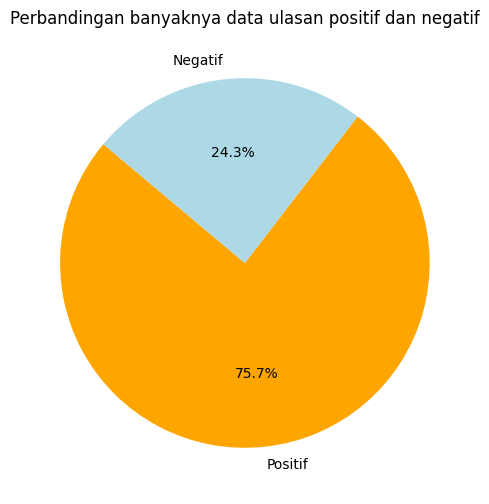

In [ ]:
jumlah_komentar = df['Label'].value_counts()

plt.figure(figsize=(8,6))
plt.pie(jumlah_komentar, labels=['Positif', 'Negatif'], autopct='%1.1f%%', startangle=140, colors=['orange', 'lightblue'])
plt.title('Perbandingan banyaknya data ulasan positif dan negatif')
plt.show()

Karena distribusi data ulasan positif dan negatif yang imbalance, pada saat nanti akan dilakukan penanganan khusu.

In [ ]:
# Pisahkan komentar positif dan negatif
ulasan_positif = df[df['Label'] == 'Positif']['Ulasan']
ulasan_negatif = df[df['Label'] == 'Negatif']['Ulasan']

kata_positif = Counter()
ulasan_positif.apply(lambda x: kata_positif.update(x.split()))

kata_negatif = Counter()
ulasan_negatif.apply(lambda x: kata_negatif.update(x.split()))

# mengetahui 10 kata yang paling sering digunakan
top_kata_positif = kata_positif.most_common(10)
top_kata_negatif = kata_negatif.most_common(10)

top_kata_positif_df = pd.DataFrame(top_kata_positif, columns=['Kata','Frekuensi'])
top_kata_negatif_df = pd.DataFrame(top_kata_negatif, columns=['Kata','Frekuensi'])

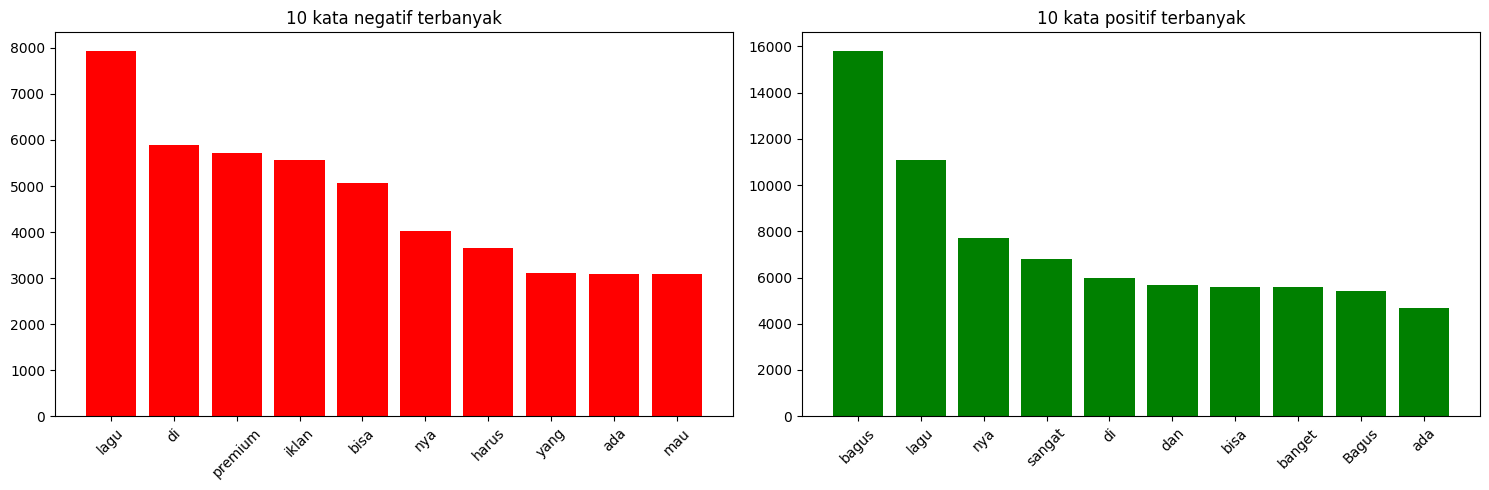

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.bar(top_kata_negatif_df['Kata'], top_kata_negatif_df['Frekuensi'], color='red')
plt.title('10 kata negatif terbanyak')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(top_kata_positif_df['Kata'], top_kata_positif_df['Frekuensi'], color='green')
plt.title('10 kata positif terbanyak')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Feature Engineering

Membagi data training dan testing

In [ ]:
X = data['Ulasan']
y = data['Label']

X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, random_state=7)

Tokenization atau penguraian kalimat menjadi kata

In [ ]:
max_kata = 1000
tokenizer = Tokenizer(num_words=max_kata)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Padding (yaitu penyetaraan banyak kata tiap ulasan)

agar tidak bingung dalam menentukan angka, maka akan diambil dari nilai tengahnya saja

In [ ]:
panjang_sequences = [len(seq) for seq in X_train_seq]

median = np.median(panjang_sequences)

print("Median data training: ",median)

Median data training:  5.0


Maka akan diambil angka 5

In [ ]:
max_panjang = 5

X_train_padded = pad_sequences(X_train_seq, maxlen=max_panjang, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_panjang, padding='post')

Label encoding

In [ ]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.fit_transform(y_test)

#Pembuatan Model

Class weight, digunakan untuk mengatasi data yang imbalance (data positif 75,7% : 24,3% data negatif)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.5608032308727844), 1: np.float64(0.7356704737732657)}


Build model

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=max_kata, output_dim=4),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='Adam',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Callback

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Training

In [ ]:
history = model.fit(
    X_train_padded,
    y_train_encoded,
    epochs=30,
    batch_size=8,
    validation_data=(X_test_padded, y_test_encoded),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/30
6957/6957 - 39s - 6ms/step - accuracy: 0.8094 - auc: 0.8701 - loss: 0.4664 - precision: 0.8987 - recall: 0.8109 - val_accuracy: 0.8085 - val_auc: 0.8873 - val_loss: 0.4496 - val_precision: 0.9166 - val_recall: 0.7883
Epoch 2/30
6957/6957 - 31s - 4ms/step - accuracy: 0.8242 - auc: 0.8876 - loss: 0.4286 - precision: 0.9125 - recall: 0.8200 - val_accuracy: 0.8187 - val_auc: 0.8903 - val_loss: 0.4275 - val_precision: 0.9107 - val_recall: 0.8112
Epoch 3/30
6957/6957 - 36s - 5ms/step - accuracy: 0.8261 - auc: 0.8920 - loss: 0.4212 - precision: 0.9143 - recall: 0.8211 - val_accuracy: 0.8257 - val_auc: 0.8936 - val_loss: 0.4152 - val_precision: 0.9032 - val_recall: 0.8311
Epoch 4/30
6957/6957 - 30s - 4ms/step - accuracy: 0.8294 - auc: 0.8983 - loss: 0.4113 - precision: 0.9173 - recall: 0.8233 - val_accuracy: 0.8362 - val_auc: 0.8980 - val_loss: 0.4011 - val_precision: 0.8986 - val_recall: 0.8540
Epoch 5/30
6957/6957 - 31s - 4ms/step - accuracy: 0.8355 - auc: 0.9039 - loss: 0.4012 - 

Plot accuracy & loss

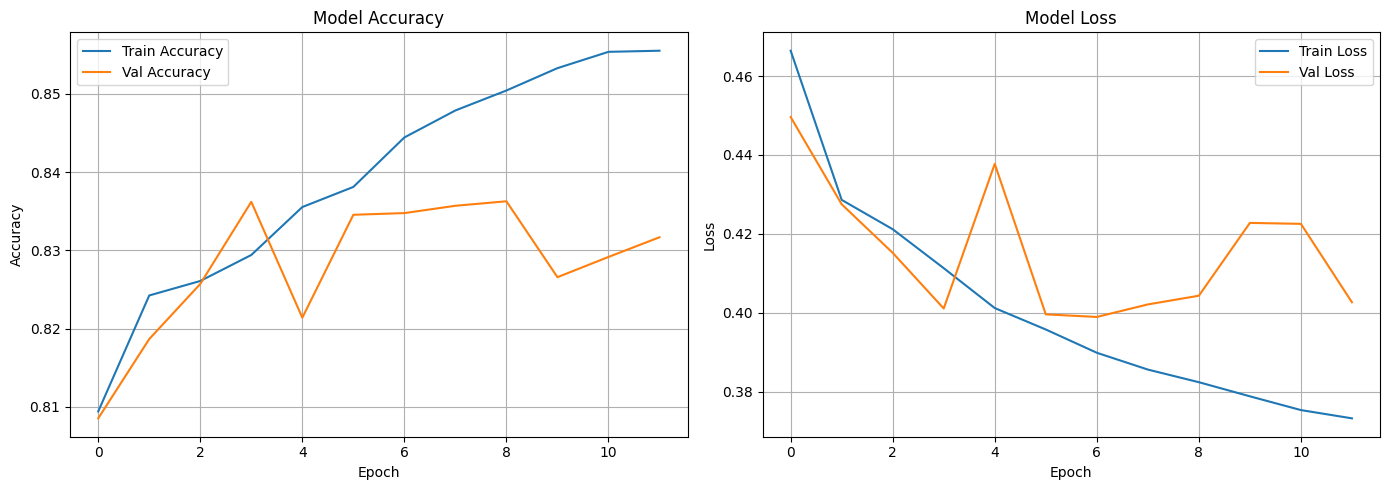

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Evaluasi

In [ ]:
print("\n── Evaluation on Test Set ──")
results = model.evaluate(X_test_padded, y_test_encoded, verbose=0)
print(f"Accuracy  : {results[1]:.4f}")
print(f"Precision : {results[2]:.4f}")
print(f"Recall    : {results[3]:.4f}")
print(f"AUC       : {results[4]:.4f}")


── Evaluation on Test Set ──
Accuracy  : 0.8348
Precision : 0.9027
Recall    : 0.8467
AUC       : 0.9006


Classification report

In [ ]:
y_pred_prob = model.predict(X_test_padded)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n── Classification Report ──")
print(classification_report(y_test_encoded, y_pred,
      target_names=['Negatif', 'Positif']))

435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

── Classification Report ──
              precision    recall  f1-score   support

     Negatif       0.72      0.81      0.76      4512
     Positif       0.90      0.85      0.87      9401

    accuracy                           0.83     13913
   macro avg       0.81      0.83      0.82     13913
weighted avg       0.84      0.83      0.84     13913



Confussion matrix

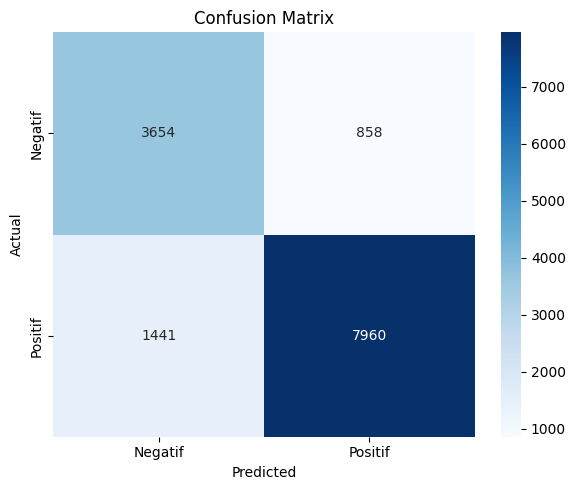

In [ ]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()